Multi-Layer Perceptron(MLP)

Multi-Layer Perceptron(MLP)

In [3]:
import numpy as np
from typing import Union, Sequence
import torch
from torch import nn
from typing import Tuple
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import PercentFormatter

plt.style.use('seaborn-v0_8')

Tensor = torch.Tensor
TensorParams = Tuple[Tensor, Tensor, Tensor, Tensor]

lr=0.01 #learning rate
batch_size=1

rng = np.random.default_rng(11)

## Manual MLP - 1‑Hidden‑Layer Neural Network Using Manual SGD optimiser, ReLU activation, and  MSE loss function

In [4]:
"""
MLP FLow is:

x
↓
Affine map (W1 x + b1)
↓
Pre‑activation a1
↓
ReLU
↓
Hidden activation h1
↓
Affine map (W2 h1 + b2)
↓
If classification required:
      Logits a2
      ↓
      Softmax/Sigmoid if binary
      ↓
      Predicted probabilities y_hat
Else (expected output like that in regression or any function result):
      Final output h2 = a2
↓
Loss (MSE/cross_entropy etc)
↓
Backward pass - compute gradients dW2, db2, dW1, db1)
↓
Optimizer step (SGD/Adam etc - updates W1, b1, W2, b2)
↓
Updates parameters, which are then fed into the next forward pass

"""

#--------------------------------------------------------------------------------------
#  Setting up XOR test data
#--------------------------------------------------------------------------------------

X = rng.uniform(-1, 1, size=(batch_size, 2)).astype(np.float64) # uniformly distributed coordinates from (-1,1),(-1,-1),(1,-1),(1,1) region
y = (X[:, 0] * X[:, 1] < 0).astype(int)

d = 2      # input dimension (x1 and x2 coordinates in X)
h = 4      # hidden layer dimension: no of dimensions = no of neurons
C = 1      # expected binary classification: either 0 or 1 (y)

"""
- W1: shape (4, 2) → maps 2‑D inputs to 4‑D hidden layer(4D is a 1d numpy array but 4 neurons are different aspects like rbg which represents a 3d space like 'x,y,z'  but stored as 1d array)
- b1: shape (4,) → one bias per hidden neuron
- W2: shape (1, 4) → maps hidden layer to single output
- b2: shape (1,) → bias for output neuron

"""
W1 = rng.normal(0, 0.1, size=(h, d)).astype(np.float64)
b1 = rng.normal(0, 0.1, size=(h,)).astype(np.float64)
W2 = rng.normal(0, 0.1, size=(C, h)).astype(np.float64)
b2 = rng.normal(0, 0.1, size=(C,)).astype(np.float64)

params = (W1,b1,W2,b2)

print("Was getting big diffs if I use float32 test data\n")

#print("\nInput W1:", W1)
#print("Input W2:", W2,"\n")

#--------------------------------------------------------------------------------------
#  Creating MLP with 1 hidden layer, using Relu optimisation - single batch
#--------------------------------------------------------------------------------------

def affine_map(x: Union[float, int, Sequence, np.ndarray], W: Union[float, int, Sequence, np.ndarray], b: Union[float, int, Sequence, np.ndarray]):
    """
    Applies the weights(initially random and then adjusted gradually so that the final loss is minimised) to the provided inputs(X). 
    The 'b' applies a bias to the WX output like a straight line y-intercept: y=mx+c
    """
    x_arr = np.asarray(x)
    W_arr = np.asarray(W)
    b_arr = np.asarray(b)

    if W_arr.ndim != 2:
        raise ValueError("W1 must be a 2D matrix")

    if x_arr.ndim != 1:
        raise ValueError(f"x must be a 1D vector but has shape {x_arr.shape}")

    if b_arr.ndim != 1:
        raise ValueError(f"b1 must be a 1D vector but has shape {b_arr.shape}")

    if W_arr.shape[1] != x_arr.shape[0]:
        raise ValueError(f"Shape mismatch: W1 has {W_arr.shape[1]} columns but x has {x_arr.shape[0]} elements")

    if b_arr.shape[0] != W_arr.shape[0]:
        raise ValueError(f"Shape mismatch: b has {b_arr.shape[0]} elements but W has {W_arr.shape[0]} rows")

    return W_arr@x_arr + b_arr;


def relu(a: Union[float, int, Sequence, np.ndarray]) -> np.ndarray:
    """
    Returns max(x, 0) element-wise; this helps to filter out negative values by marking them 0  and only keep the positives
    """
    a_arr = np.asarray(a)
    return np.maximum(a_arr, 0)

def relu_prime(u: Union[float, int, Sequence, np.ndarray]) -> np.ndarray:
    u_arr = np.asarray(u)
    return (u_arr > 0).astype(u_arr.dtype) #cast back from bool to the original input type

    
def loss_f(y_hat: Union[float, int, Sequence, np.ndarray], y: Union[float, int, Sequence, np.ndarray]) -> np.ndarray:
    """
    Mean Square Error loss function
    """    
    y_hat_arr = np.asarray(y_hat)
    y_arr = np.asarray(y)
    
    if y_hat_arr.ndim != 1:
        raise ValueError("Predicted values must be a 1D vector of shape (batch size,)")
        
    if y_arr.ndim != 1:
        print(y_hat, y_hat.shape)
        raise ValueError("y must be a 1D vector of shape (batch size,)")
        
    if y_hat_arr.shape[0] != y_arr.shape[0]:
        raise ValueError("predicted_values and y must have the same length")
    
    return 0.5*(y_hat_arr-y_arr)**2

def loss_f_prime(y_hat: Union[float, int, Sequence, np.ndarray], y: Union[float, int, Sequence, np.ndarray]) -> np.ndarray:
    y_hat_arr = np.asarray(y_hat)
    y_arr = np.asarray(y)
    
    if y_hat_arr.ndim != 1:
        raise ValueError("Predicted values must be a 1D vector of shape (batch size-h,)")
        
    if y_arr.ndim != 1:
        raise ValueError("y must be a 1D vector of shape (h,)")
        
    if y_hat_arr.shape[0] != y_arr.shape[0]:
        raise ValueError("predicted_values and y must have the same length")
    
    return (y_hat_arr-y_arr)

def forward_pass(x_te, y_te, params):
    """
    Performs the forward pass of a 3‑layer MLP.

    1. The input vector x_te is fed into the first affine map:
           a1 = W1 @ x_te + b1
       This produces the pre‑activation values for the hidden layer.

    2. A ReLU activation is applied:
           h1 = ReLU(a1)
       ReLU does NOT measure closeness to the expected output, it simply
       filters out -ve values by making them 0 and keeps +ve ones.

    3. The hidden activations are passed through the second affine map:
           a2 = W2 @ h1 + b2
       This produces the final logits.

    4. Depending on the task:
       - For binary classification, a sigmoid can be applied to convert
         logits into probabilities.
       - For multi‑class classification, a softmax can be applied to
         convert logits into a probability distribution over classes.

    The function returns the probability distribution which can then be 
    compared to y_te using a loss function.
    """
    x_te_arr = np.asarray(x_te)
    y_te_arr = np.asarray(y_te)

    (W1,b1, W2,b2) = params

    #print("W1", W1.shape)
    #print("b1", b1.shape)
    #print("W2", W2.shape)
    #print("b2", b2.shape)
    
    # forward pass
    a1=affine_map(x_te_arr, W1, b1)
    h1=relu(a1)
    a2=affine_map(h1, W2, b2)

    #print("a1", a1.shape)
    #print("h1", h1.shape)
    #print("a2", a2.shape)
    
    y_hat = 1 / (1 + np.exp(-a2)) # convert the expected binary outputs to probabilities using sigmoid
    
    return  (a1, h1, y_hat)  
    
def run_backward_pass(x0: Union[float, int, Sequence, np.ndarray], 
                      y_hat: Union[float, int, Sequence, np.ndarray], 
                      y_te: Union[float, int, Sequence, np.ndarray],
                      h1: Union[float, int, Sequence, np.ndarray],
                      a1: Union[float, int, Sequence, np.ndarray], params):    
    """
    Computes the gradient because of each param used in this 1-hidden layered MLP.

    Applies chain rule to backpropagate the loss across this network. 
        loss->logits(y_hat)->signoid->a2->h1->Relu->a1->x
    """
    x0 = np.asarray(x0)
    y_hat = np.asarray(y_hat)
    y_te = np.asarray(y_te)
    h1 = np.asarray(h1)
    a1 = np.asarray(a1)
    
    #print("x0 shape:", x0.shape)
    #print("y_te shape:", y_te.shape)

    #print("y_hat shape:", y_hat.shape)    
    #print("a1 shape:", a1.shape)
    #print("h1 shape:", h1.shape)
    
    (W1,b1, W2,b2) = params
    
    #df = np.asarray(loss_f_prime(y_hat, y_te))
    #print("df shape:", df.shape)
    #sig_prime = y_hat * (1 - y_hat)
    #print("sig_prime shape:", sig_prime.shape)
    dL_da2 = (y_hat - y_te) * (y_hat * (1 - y_hat))
    dL_da2 = float(np.asarray(dL_da2).item())
    #print("dL_da2 shape:", dL_da2.shape)
    
    # output layer
    dW2 = dL_da2 * h1.reshape(1, -1)
    #print("dW2 shape:", dW2.shape)
    db2 = dL_da2
    #print("db2 shape:", db2.shape)
    
    # backprop into hidden layer
    dh1 = W2.T.flatten() * dL_da2
    #print("dh1 shape:", dh1.shape)
    da1 = dh1 * relu_prime(a1)
    #print("da1 shape:", da1.shape)
    
    # input layer
    dW1 = da1.reshape(-1,1) @ x0.reshape(1,-1)
    #print("dW1 shape:", dW1.shape)
    db1 = da1
    #print("db1 shape:", db1.shape)

    return (dW1, db1, dW2,db2)

def run_analytical_model(x_te: Union[float, int, Sequence, np.ndarray], y_te: Union[float, int, Sequence, np.ndarray], params):    
    (a1, h1, y_hat) = forward_pass(x_te, y_te, params)
    #mse=loss_f(y_hat, y_te)  # compute the loss and later its gradient using the sigmoid probability
    
    #print("mse", mse.shape, mse)

    (dW1, db1, dW2,db2) = run_backward_pass(x_te, y_hat, y_te, h1, a1, params)
    (W1,b1, W2,b2) = params
   
    #print("dW2", dW2.shape)
    #print("dh1", dh1.shape)
    #print("da1", da1.shape)
    #print("dW1", dW1.shape)
    #print("db1", db1.shape)
    #print("W2", W2.shape)
    #print("W1", W1.shape)
    
    #print("\nNew W1:", W1)
    #print("New W2:", W2,"\n")
    
    return (dW1, db1, dW2,db2)

def run_numerical_fwd_backward_pass(X_te: Union[float, int, Sequence, np.ndarray],                       
                      y_te: Union[float, int, Sequence, np.ndarray],
                      params, delta_params, e, idx):    
    (i,j) = idx # i=>h, j=>d
    W1, b1, W2, b2 = params
    dW1, db1, dW2, db2 = delta_params


    # dW1
    W1_minus = W1.copy()
    W1_plus  = W1.copy()

    W1_minus[i, j] -= e
    _, _, y_minus = forward_pass(X_te, y_te, (W1_minus, b1, W2, b2))
    minus = loss_f(y_minus, y_te)

    W1_plus[i, j] += e
    _, _, y_plus = forward_pass(X_te, y_te, (W1_plus, b1, W2, b2))
    plus = loss_f(y_plus, y_te)

    dW1[i, j] = central_mean(plus, minus, e)

    # db1
    b1_minus = b1.copy()
    b1_plus  = b1.copy()
    
    b1_minus[i] = b1_minus[i] - e;
    _, _, y_hat = forward_pass(X_te, y_te, (W1,b1_minus, W2,b2))
    minus = loss_f(y_hat, y_te)

    b1_plus[i] += e;
    _, _, y_hat = forward_pass(X_te, y_te, (W1,b1_plus, W2,b2))
    plus = loss_f(y_hat, y_te)        

    db1[i] = central_mean(plus, minus, e)
    
    # dW2
    W2_minus = W2.copy()
    W2_plus  = W2.copy()

    W2_minus[0, i] -= e
    _, _, y_hat = forward_pass(X_te, y_te, (W1,b1, W2_minus,b2))
    minus = loss_f(y_hat, y_te)

    W2_plus[0, i] += e
    _, _, y_hat = forward_pass(X_te, y_te, (W1,b1, W2_plus,b2))
    plus = loss_f(y_hat, y_te)

    dW2[:, i] = central_mean(plus, minus, e)
    
    # db2
    b2_minus = b2.copy()
    b2_plus  = b2.copy()

    b2_minus -= e;
    _, _, y_hat = forward_pass(X_te, y_te, (W1,b1, W2,b2_minus))
    minus = loss_f(y_hat, y_te)

    b2_plus += e;
    _, _, y_hat = forward_pass(X_te, y_te, (W1,b1, W2,b2_plus))
    plus = loss_f(y_hat, y_te)
    
    db2[0] = central_mean(plus, minus, e)
    
    return (dW1, db1, dW2,db2)
       
def run_numerical_model(x_te: Union[float, int, Sequence, np.ndarray], y_te: Union[float, int, Sequence, np.ndarray], params, e, h_idx_arr, d_idx_arr):
    (W1,b1, W2,b2) = params
    
    dW1 = np.zeros_like(W1)
    db1 = np.zeros_like(b1)
    dW2 = np.zeros_like(W2)
    db2 = np.zeros_like(b2)

    for h_idx in h_idx_arr:
        for d_idx in d_idx_arr:
            (dW1, db1, dW2,db2) = run_numerical_fwd_backward_pass(x_te, y_te, params, (dW1, db1, dW2,db2), e, (h_idx, d_idx))
    
    # return the final results
    return (dW1, db1, dW2,db2)
    
def central_mean(plus, minus, e):
    return ((plus-minus)/(2.0*e)).item()


def comparison(analytical, numerical, h_idx_arr, d_idx_arr):
    (dW1_a, db1_a, dW2_a, db2_a) = analytical
    (dW1_n, db1_n, dW2_n, db2_n) = numerical
    
    dW1_n = np.asarray(dW1_n)
    db1_n = np.asarray(db1_n)
    dW2_n = np.asarray(dW2_n)
    db2_n = np.asarray(db2_n)
    
    
    diffs_dW1 = []
    for h_idx in h_idx_arr:
        for d_idx in d_idx_arr:
            a = dW1_a[h_idx, d_idx]
            n = dW1_n[h_idx, d_idx]
            diff = abs(a - n)/(abs(a) + abs(n) + 1e-12)
            diffs_dW1.append((h_idx, d_idx, a, n, diff))

    # b1 only h dimension
    diffs_db1 = []
    for h_idx in h_idx_arr:
        a = db1_a[h_idx]
        n = db1_n[h_idx]
        diff = abs(a - n)/(abs(a) + abs(n) + 1e-12)
        diffs_db1.append((h_idx, d_idx, a, n, diff))

    # dW2 only h dimension
    diffs_dW2 = []
    for h_idx in h_idx_arr:
        a = dW2_a[0, h_idx]
        n = dW2_n[0, h_idx]
        diff = abs(a - n)/(abs(a) + abs(n) + 1e-12)
        diffs_dW2.append((h_idx, d_idx, a, n, diff))

    # b2 is single value, scalar
    a = db2_a
    n = db2_n
    diff = abs(a - n)/(abs(a) + abs(n) + 1e-12)
    diff_db2 = (h_idx, d_idx, a, n, diff)
    
    return (diffs_dW1, diffs_db1, diffs_dW2, diff_db2)

def print_max_results(title, results):    
    print("\n" + title)
    print("-" * 35)

    # Header
    print(f"{'Parameter':<20} {'Relative Error':>15}")
    print("-" * 35)

    # Rows
    for key, value in results.items():       
        print(f"{key:<20} {value:>15.6e}")

    print("-" * 35)

def print_results(title, results):
    print("\n" + title)
    print("-" * 70)

    print(f"{'h':<5} {'d':<5} {'Analytical':>15} {'Numerical':>15} {'Relative Error':>15}")
    print("-" * 70)
    
    # Rows
    for (h, d, a, n, diff) in results:
        print(
            f"{h:<5d} "
            f"{d:<5d} "
            f"{a:>15.8f} "
            f"{n:>15.8f} "
            f"{diff:>15.8e}"
    )

    print("-" * 70)

    
# ---------------------------------------------------------
# Run all experiments
# ---------------------------------------------------------

#using 1 sample only
x0=X[0]
y0=y[0:1]

h_idx_arr = rng.integers(0, h, size=5)
h_idx_arr.sort()
d_idx_arr = rng.integers(0, d, size=2)
d_idx_arr.sort()


analytical_output_params = run_analytical_model(x0, y0, params)
numerical_output_params_1 = run_numerical_model(x0, y0, params, 1e-5, h_idx_arr, d_idx_arr)
numerical_output_params_2 = run_numerical_model(x0, y0, params, 1e-4, h_idx_arr, d_idx_arr)
numerical_output_params_3 = run_numerical_model(x0, y0, params, 1e-3, h_idx_arr, d_idx_arr)

(diffs_dW1_1, diffs_db1_1, diffs_dW2_1, diff_db2_1) = comparison(
    analytical_output_params,
    numerical_output_params_1,
    h_idx_arr,
    d_idx_arr
)

results_1 = {        
        "dW1_max_rel_error": max(np.array(diffs_dW1_1)[:, 4]),
        "db1_max_rel_error": max(np.array(diffs_db1_1)[:, 4]),
        "dW2_max_rel_error": max(np.array(diffs_dW2_1)[:, 4]),
        "db2_rel_error": diff_db2_1[4].item(),
    }

(diffs_dW1_2, diffs_db1_2, diffs_dW2_2, diff_db2_2) = comparison(
    analytical_output_params,
    numerical_output_params_2,
    h_idx_arr,
    d_idx_arr
)
results_2 = {        
        "dW1_max_rel_error": max(np.array(diffs_dW1_2)[:, 4]),
        "db1_max_rel_error": max(np.array(diffs_db1_2)[:, 4]),
        "dW2_max_rel_error": max(np.array(diffs_dW2_2)[:, 4]),
        "db2_rel_error": diff_db2_2[4].item(),
    }

(diffs_dW1_3, diffs_db1_3, diffs_dW2_3, diff_db2_3) = comparison(
    analytical_output_params,
    numerical_output_params_3,
    h_idx_arr,
    d_idx_arr
)
results_3 = {        
        "dW1_max_rel_error": max(np.array(diffs_dW1_3)[:, 4]),
        "db1_max_rel_error": max(np.array(diffs_db1_3)[:, 4]),
        "dW2_max_rel_error": max(np.array(diffs_dW2_3)[:, 4]),
        "db2_error": diff_db2_3[4].item(),
    }   
print_max_results("Gradient Check (e = 1e-5)", results_1)
print_max_results("Gradient Check (e = 1e-4)", results_2)
print_max_results("Gradient Check (e = 1e-3)", results_3)

print_results("Gradient Check dW1 (e = 1e-5)", diffs_dW1_1)
print_results("Gradient Check dW1 (e = 1e-4)", diffs_dW1_2)
print_results("Gradient Check dW1 (e = 1e-3)", diffs_dW1_3)

print('Analytical and Numeric gradients are very close')

Was getting big diffs if I use float32 test data


Gradient Check (e = 1e-5)
-----------------------------------
Parameter             Relative Error
-----------------------------------
dW1_max_rel_error       2.345141e-10
db1_max_rel_error       9.212409e-11
dW2_max_rel_error       2.280161e-10
db2_rel_error           1.410811e-12
-----------------------------------

Gradient Check (e = 1e-4)
-----------------------------------
Parameter             Relative Error
-----------------------------------
dW1_max_rel_error       6.395302e-12
db1_max_rel_error       1.073762e-11
dW2_max_rel_error       1.532949e-11
db2_rel_error           4.069447e-10
-----------------------------------

Gradient Check (e = 1e-3)
-----------------------------------
Parameter             Relative Error
-----------------------------------
dW1_max_rel_error       1.525084e-10
db1_max_rel_error       2.773297e-10
dW2_max_rel_error       1.773967e-10
db2_error               4.071084e-08
--------------------------

## PyTorch re-implementation without autograd

In [5]:
def forward_pass_pytorch(x: Tensor, params: TensorParams) -> Tensor:
    (W1, b1, W2, b2) = params

    a1_te = W1 @ x + b1
    h1_te = torch.relu(a1_te)
    a2_te = W2 @ h1_te + b2
    y_hat_te = torch.sigmoid(a2_te)

    return h1_te, a1_te, y_hat_te

def loss_f_pytorch(y_hat_te: Tensor, y_te: Tensor) -> Tensor:
    return 0.5*(y_hat_te-y_te)**2

def loss_f_prime_pytorch(y_hat_te: Tensor, y_te: Tensor) -> Tensor:   
    return (y_hat_te-y_te)

def relu_prime_pytorch(x:Tensor):
    return (x > 0).to(x.dtype)
    
def run_backward_pass_pytorch(x: Tensor, y_hat: Tensor, y_te: Tensor, h1: Tensor, a1: Tensor, params: TensorParams):    
    df = loss_f_prime_pytorch(y_hat, y_te)
    
    (W1,b1, W2,b2) = params
    
    dL_da2 = (y_hat - y_te) * (y_hat * (1 - y_hat))
    dL_da2 = float(np.asarray(dL_da2).item())
    #print("dL_da2 shape:", dL_da2.shape)
    
    # output layer
    dW2 = dL_da2 * h1.reshape(1, -1)
    #print("dW2 shape:", dW2.shape)
    db2 = dL_da2
    #print("db2 shape:", db2.shape)
    
    # backprop into hidden layer
    dh1 = W2.T.flatten() * dL_da2
    #print("dh1 shape:", dh1.shape)
    da1 = dh1 * relu_prime(a1)
    #print("da1 shape:", da1.shape)
    
    # input layer
    dW1 = da1.reshape(-1,1) @ x.reshape(1,-1)
    #print("dW1 shape:", dW1.shape)
    db1 = da1
    #print("db1 shape:", db1.shape)

    return (dW1, db1, dW2,db2)
    
def run_model_pytorch_nograd(x_te: Tensor, y_te: Tensor, params: TensorParams):
    (W1,b1, W2,b2) = params
    
    with torch.no_grad():
        h1_te, a1_te, y_hat_te = forward_pass_pytorch(x_te, params)
        mse=loss_f_pytorch(y_hat_te, y_te) 
        
        (dW1, db1, dW2,db2) = run_backward_pass_pytorch(x_te, y_hat_te, y_te, h1_te, a1_te,params)
        
    
    return (dW1, db1, dW2,db2)

    

# ---------------------------------------------------------
# Run all experiments
# ---------------------------------------------------------
X_tensor_te = [torch.tensor(a, dtype=torch.float64) for a in X]
y_tensor_te = [torch.tensor(a, dtype=torch.float64) for a in y]

#using 1 sample only
x0_tensor=X_tensor_te[0]
y0_tensor = y_tensor_te[0].unsqueeze(0)

W1_tensor = torch.tensor(W1, dtype=torch.float64)
b1_tensor = torch.tensor(b1, dtype=torch.float64)
W2_tensor = torch.tensor(W2, dtype=torch.float64)
b2_tensor = torch.tensor(b2, dtype=torch.float64)

dW1_t, db1_t, dW2_t, db2_t = run_model_pytorch_nograd(x0_tensor, y0_tensor, (W1_tensor,b1_tensor,W2_tensor,b2_tensor))

pytorch_no_autograd_output_params_as_np = (dW1_t.numpy(), db1_t.numpy(), dW2_t.numpy(), db2_t)
(diffs_dW1_4, diffs_db1_4, diffs_dW2_4, diff_db2_4) = comparison(
    numerical_output_params_1,
    pytorch_no_autograd_output_params_as_np,
    h_idx_arr,
    d_idx_arr
)
results_4 = {        
        "dW1_max_rel_error": max(np.array(diffs_dW1_4)[:, 4]),
        "db1_max_rel_error": max(np.array(diffs_db1_4)[:, 4]),
        "dW2_max_rel_error": max(np.array(diffs_dW2_4)[:, 4]),
        "db2_rel_error": diff_db2_4[4].item(),
    }
print_max_results("Pytorch-NoAutoGrad", results_4)
print_results("Gradient Check dW1 (e = 1e-5 Pytorch-NoAutoGrad)", diffs_dW1_4)


Pytorch-NoAutoGrad
-----------------------------------
Parameter             Relative Error
-----------------------------------
dW1_max_rel_error       2.345141e-10
db1_max_rel_error       9.212409e-11
dW2_max_rel_error       2.280161e-10
db2_rel_error           1.410811e-12
-----------------------------------

Gradient Check dW1 (e = 1e-5 Pytorch-NoAutoGrad)
----------------------------------------------------------------------
h     d          Analytical       Numerical  Relative Error
----------------------------------------------------------------------
0     0          0.00349349      0.00349349  2.34514056e-10
0     0          0.00349349      0.00349349  2.34514056e-10
2     0         -0.00759811     -0.00759811  1.07759697e-10
2     0         -0.00759811     -0.00759811  1.07759697e-10
3     0          0.00000000      0.00000000  0.00000000e+00
3     0          0.00000000      0.00000000  0.00000000e+00
3     0          0.00000000      0.00000000  0.00000000e+00
3     0        

C:\Users\prolo\AppData\Local\Temp\ipykernel_9248\2585965152.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  da1 = dh1 * relu_prime(a1)


## PyTorch with autograd

In [6]:
def run_model_pytorch_autograd(X_te: Tensor, y_te: Tensor, params: TensorParams):
    (W1,b1, W2,b2) = params
    h1_te, a1_te, y_hat_te = forward_pass_pytorch(X_te, params)
    #loss = torch.nn.functional.mse_loss(y_hat_te, y_te)   # getting half the grad value compared to muneric with this
    loss=loss_f_pytorch(y_hat_te, y_te)
    loss.backward()

    dW1 = W1.grad.detach().clone()
    db1 = b1.grad.detach().clone()
    dW2 = W2.grad.detach().clone()
    db2 = b2.grad.detach().clone()

    # clear grads
    for p in params:
        p.grad.zero_()

    return dW1, db1, dW2, db2

# ---------------------------------------------------------
# Run all experiments
# ---------------------------------------------------------
X_tensor_te = [torch.tensor(a, dtype=torch.float64) for a in X]
y_tensor_te = [torch.tensor(a, dtype=torch.float64) for a in y]

#using 1 sample only
x0_tensor=X_tensor_te[0]
y0_tensor = y_tensor_te[0].unsqueeze(0)

W1_tensor_a = torch.tensor(W1, dtype=torch.float64, requires_grad=True)
b1_tensor_a = torch.tensor(b1, dtype=torch.float64, requires_grad=True)
W2_tensor_a = torch.tensor(W2, dtype=torch.float64, requires_grad=True)
b2_tensor_a = torch.tensor(b2, dtype=torch.float64, requires_grad=True)

dW1_t_a, db1_t_a, dW2_t_a, db2_t_a = run_model_pytorch_autograd(x0_tensor, y0_tensor.to(torch.float64), (W1_tensor_a,b1_tensor_a,W2_tensor_a,b2_tensor_a))

pytorch_autograd_output_params_as_np = (dW1_t_a.detach().numpy(), db1_t_a.detach().numpy(), dW2_t_a.detach().numpy(), db2_t_a.detach().numpy())

(diffs_dW1_5, diffs_db1_5, diffs_dW2_5, diff_db2_5) = comparison(
    numerical_output_params_1,
    pytorch_autograd_output_params_as_np,
    h_idx_arr,
    d_idx_arr
)
results_5 = {        
        "dW1_max_rel_error": max(np.array(diffs_dW1_5)[:, 4]),
        "db1_max_rel_error": max(np.array(diffs_db1_5)[:, 4]),
        "dW2_max_rel_error": max(np.array(diffs_dW2_5)[:, 4]),
        "db2_rel_error": diff_db2_5[4].item(),
    }
print_max_results("Pytorch-AutoGrad", results_5)
print_results("Gradient Check dW1 (e = 1e-5 Pytorch-AutoGrad)", diffs_dW1_5)



Pytorch-AutoGrad
-----------------------------------
Parameter             Relative Error
-----------------------------------
dW1_max_rel_error       2.345141e-10
db1_max_rel_error       9.212409e-11
dW2_max_rel_error       2.280161e-10
db2_rel_error           1.410811e-12
-----------------------------------

Gradient Check dW1 (e = 1e-5 Pytorch-AutoGrad)
----------------------------------------------------------------------
h     d          Analytical       Numerical  Relative Error
----------------------------------------------------------------------
0     0          0.00349349      0.00349349  2.34514056e-10
0     0          0.00349349      0.00349349  2.34514056e-10
2     0         -0.00759811     -0.00759811  1.07759697e-10
2     0         -0.00759811     -0.00759811  1.07759697e-10
3     0          0.00000000     -0.00000000  0.00000000e+00
3     0          0.00000000     -0.00000000  0.00000000e+00
3     0          0.00000000     -0.00000000  0.00000000e+00
3     0          0.

## Using nn module

In [7]:
class TinyMLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim): #d,h,c
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), 
                                nn.ReLU(),
                                nn.Linear(hidden, out_dim),
                                nn.Sigmoid())
    def forward(self, x):
        return self.net(x)  # logits

model = TinyMLP(d,h,C).double()
opt = torch.optim.SGD(model.parameters(), lr)
#loss_fn = nn.MSELoss(reduction='sum') #using mse to keep in sync with prev implementation else will prefer CrossEntropyLoss 

def run_model_pytorch_autograd_nn(X: Tensor, y: Tensor, params: TensorParams):
    (W1,b1,W2,b2) = params
    
    #for p in params:
    #    print(p.detach().cpu().numpy())
        
    with torch.no_grad():
        model.net[0].weight.copy_(torch.tensor(W1, dtype=torch.float64))
        model.net[0].bias.copy_(torch.tensor(b1, dtype=torch.float64))
        model.net[2].weight.copy_(torch.tensor(W2, dtype=torch.float64))
        model.net[2].bias.copy_(torch.tensor(b2, dtype=torch.float64))

    #for name, p in model.named_parameters():
    #    print(name, p.detach().cpu().numpy())
    
    model.train()
        
    W1 = model.net[0].weight
    b1 = model.net[0].bias
    W2 = model.net[2].weight
    b2 = model.net[2].bias

    logits = model(X)
    
    #loss = loss_fn(logits, y)
    loss = 0.5 * ((logits - y)**2).sum()
    
    opt.zero_grad()
    loss.backward()
    opt.step()
    
    #print('NN MSE Loss: ', loss)
    dW1 = W1.grad.detach().clone()
    db1 = b1.grad.detach().clone()
    dW2 = W2.grad.detach().clone()
    db2 = b2.grad.detach().clone()
    #print('NN MSE Loss Grads: ', dW1, db1, dW2, db2)

    return dW1, db1, dW2, db2

# ---------------------------------------------------------
# Run all experiments
# ---------------------------------------------------------

dW1_t_a_nn, db1_t_a_nn, dW2_t_a_nn, db2_t_a_nn = run_model_pytorch_autograd_nn(x0_tensor, y0_tensor.to(torch.float64), (W1_tensor_a,b1_tensor_a,W2_tensor_a,b2_tensor_a))

pytorch_autograd_nn_output_params_as_np = (dW1_t_a_nn.detach().numpy(), db1_t_a_nn.detach().numpy(), dW2_t_a_nn.detach().numpy(), db2_t_a_nn.detach().numpy())

(diffs_dW1_pytorch, diffs_db1_pytorch, diffs_dW2_pytorch, diff_db2_pytorch) = comparison(
    pytorch_autograd_nn_output_params_as_np,
    numerical_output_params_1,
    h_idx_arr,
    d_idx_arr
)
results_pytorch = {        
        "dW1_max_rel_error": max(np.array(diffs_dW1_pytorch)[:, 4]),
        "db1_max_rel_error": max(np.array(diffs_db1_pytorch)[:, 4]),
        "dW2_max_rel_error": max(np.array(diffs_dW2_pytorch)[:, 4]),
        "db2_rel_error": diff_db2_pytorch[4].item(),
    }
print_max_results("Pytorch-AutoGrad-NN-MSELoss", results_pytorch)
print_results("Gradient Check dW1 (e = 1e-5 Pytorch-AutoGrad-NN-MSELoss)", diffs_dW1_pytorch)

loss_fn = nn.CrossEntropyLoss()

dW1_t_a_nn, db1_t_a_nn, dW2_t_a_nn, db2_t_a_nn = run_model_pytorch_autograd_nn(x0_tensor, y0_tensor.to(torch.float64), (W1_tensor_a,b1_tensor_a,W2_tensor_a,b2_tensor_a))

pytorch_autograd_nn_output_params_as_np = ( dW1_t_a_nn.detach().numpy(), db1_t_a_nn.detach().numpy(), dW2_t_a_nn.detach().numpy(), db2_t_a_nn.detach().numpy())

(diffs_dW1_pytorch, diffs_db1_pytorch, diffs_dW2_pytorch, diff_db2_pytorch) = comparison(
    pytorch_autograd_nn_output_params_as_np,
    numerical_output_params_1,
    h_idx_arr,
    d_idx_arr
)
results_pytorch = {        
        "dW1_max_rel_error": max(np.array(diffs_dW1_pytorch)[:, 4]),
        "db1_max_rel_error": max(np.array(diffs_db1_pytorch)[:, 4]),
        "dW2_max_rel_error": max(np.array(diffs_dW2_pytorch)[:, 4]),
        "db2_rel_error": diff_db2_pytorch[4].item(),
    }
print_max_results("Pytorch-AutoGrad-NN-CrossEntropyLoss", results_pytorch)
print_results("Gradient Check dW1 (e = 1e-5 Pytorch-AutoGrad-NN-CrossEntropyLoss)", diffs_dW1_pytorch)

print('\nNumerical and PyTorch numbers are very close, validating the numbers from both approaches. Had to make sure PyTorch is using float64 otherwise loss of precision gives diffs\n')


Pytorch-AutoGrad-NN-MSELoss
-----------------------------------
Parameter             Relative Error
-----------------------------------
dW1_max_rel_error       2.345141e-10
db1_max_rel_error       9.212409e-11
dW2_max_rel_error       2.280161e-10
db2_rel_error           1.410811e-12
-----------------------------------

Gradient Check dW1 (e = 1e-5 Pytorch-AutoGrad-NN-MSELoss)
----------------------------------------------------------------------
h     d          Analytical       Numerical  Relative Error
----------------------------------------------------------------------
0     0          0.00349349      0.00349349  2.34514056e-10
0     0          0.00349349      0.00349349  2.34514056e-10
2     0         -0.00759811     -0.00759811  1.07759697e-10
2     0         -0.00759811     -0.00759811  1.07759697e-10
3     0         -0.00000000      0.00000000  0.00000000e+00
3     0         -0.00000000      0.00000000  0.00000000e+00
3     0         -0.00000000      0.00000000  0.00000000e+

C:\Users\prolo\AppData\Local\Temp\ipykernel_9248\2048799693.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model.net[0].weight.copy_(torch.tensor(W1, dtype=torch.float64))
C:\Users\prolo\AppData\Local\Temp\ipykernel_9248\2048799693.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model.net[0].bias.copy_(torch.tensor(b1, dtype=torch.float64))
C:\Users\prolo\AppData\Local\Temp\ipykernel_9248\2048799693.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model.net[2].weight.copy_(torch.tensor(W2, dtype=torch.float64))
C:\Users\pro

## Training and evalauting batches in Pytorch - using default float32 inputs and moon dataset

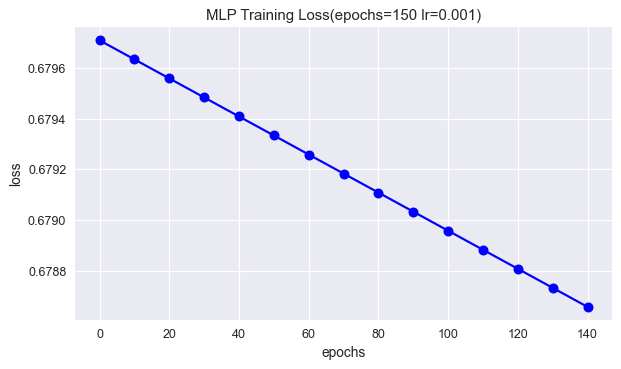

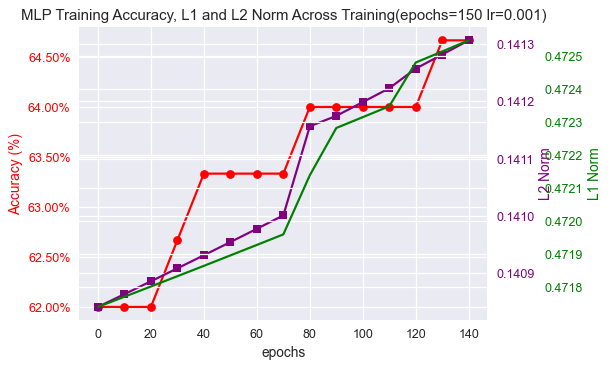

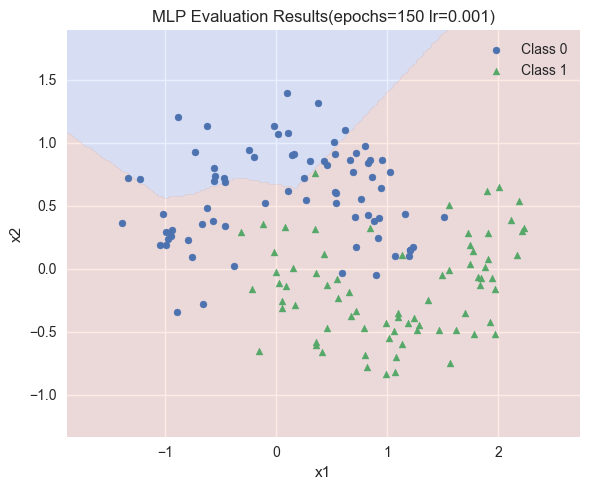

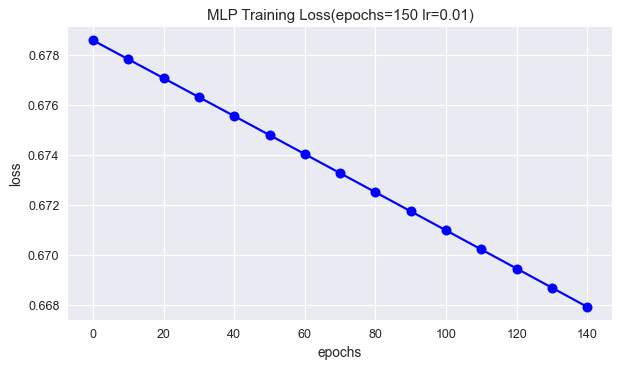

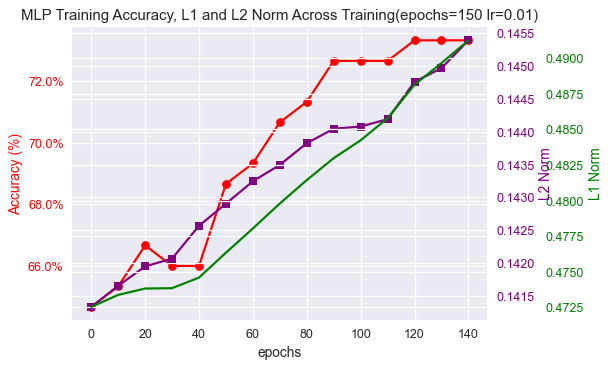

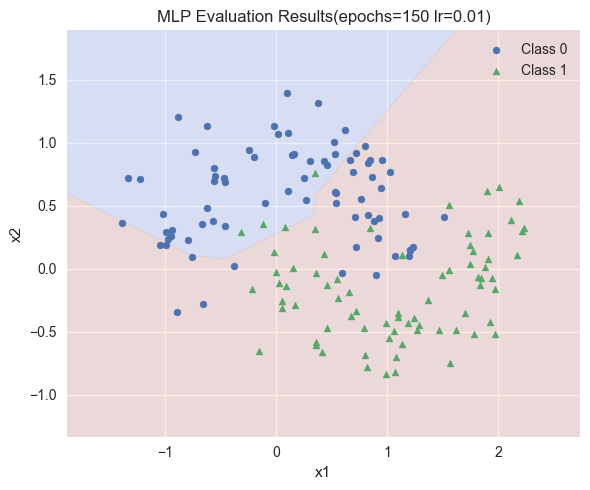

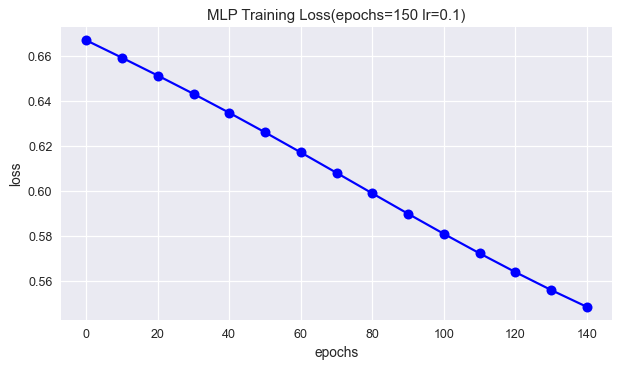

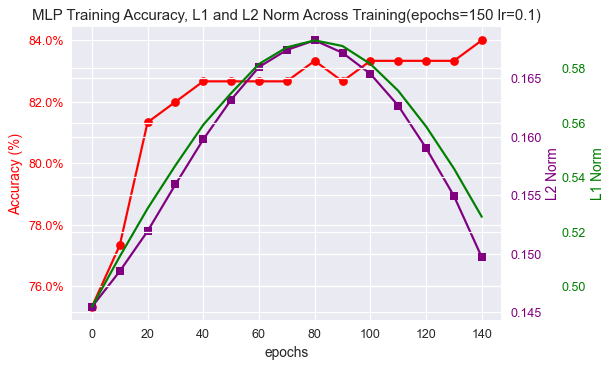

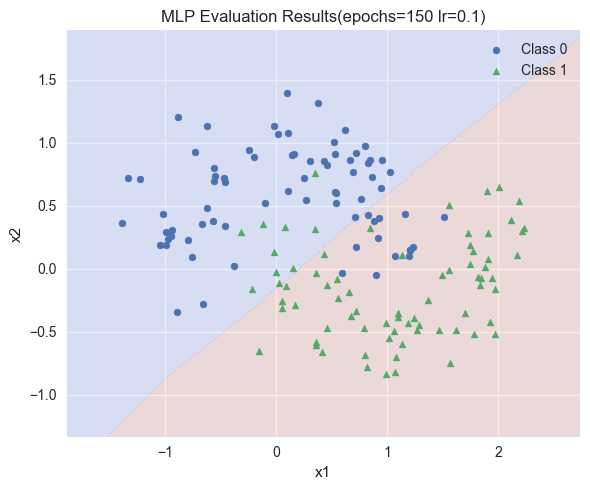


OBSERVATIONS:
- The loss graph stays the same across different learning rates and has a straight downward slope.The smooth downward slope imples it is learning properly.

- The L1-Norm(sum of abs values) graphs are moving upwards in a zig zag way implying the no of negatives are decreasing and morenetrons are active which is a healthy pattern.
But a high learning rate of 0.1 results in a downward facing parabolafrom ~80 epochs implying the no of active netrons started falling down

- The L2-Norm(sq root of sum of squared values) graphs are moving upwards in a zig zag way gradually implying a healthy learning by the model.
But a high learning rate of 0.1 results in a downward facing parabola from ~80 epochs implying the no of active netrons started falling down

- TheAccuracy graphs are moving upwards with jumps and becomes constant towrds the end.A higher learning rate results in better accuracy.
But if seen together with L1 and L2 can be seen that 0.1 learning rate is likely to be ov

In [14]:
torch.manual_seed(0)

X, y = make_moons(n_samples=600, noise=0.25, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
X_tr, X_te = map(lambda a: torch.tensor(a, dtype=torch.float32), (X_tr, X_te))
y_tr, y_te = map(lambda a: torch.tensor(a, dtype=torch.long), (y_tr, y_te))

d=2  # no of features 
h=16 # no of hidden layer neurons
C=2  # no of classifications

# Input(N,2)-> 1st linear layer{w1(2,16), b(16,)} -> Relu {h(N, 16) -> 2nd linear layer{w2(16,2), b(2,)} -> Output logits(N,2)->Classifier
W1 = torch.nn.Parameter(torch.randn(2, 16) * 0.5)
b1 = torch.nn.Parameter(torch.zeros(16))
W2 = torch.nn.Parameter(torch.randn(16, 2) * 0.5)
b2 = torch.nn.Parameter(torch.zeros(2))

params = [W1, b1, W2, b2]

model = TinyMLP(d,h,C)
loss_fn = nn.CrossEntropyLoss()

def train_epoch(model, X, y, lr):
    opt = torch.optim.SGD(model.parameters(), lr)
    model.train()
    logits = model(X)
    loss = loss_fn(logits, y)
    opt.zero_grad(); loss.backward(); opt.step()
    return float(loss)

def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
    return (logits, accuracy(logits, y))
    
def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()

def plot_diagnostics(epochs, lr, training_loss_hist, test_accuracy_hist, test_norm1_hist, test_norm2_hist):
    fig, ax = plt.subplots(figsize=(7, 4), dpi=90)
    ax.set_xlabel('epochs')
    ax.set_ylabel('loss')
    ax.plot([e for e in range(epochs) if e%10 ==0], training_loss_hist, marker='o', color='blue', markersize=8)    
    fig.tight_layout()
    ax.set_title(f"MLP Training Loss(epochs={epochs} lr={lr})")
    plt.show()

    
    fig, ax1 = plt.subplots(figsize=(7, 4), dpi=90)
    epochs_axis = [e for e in range(epochs) if e % 10 == 0]
    
    # accuracy
    ax1.plot(epochs_axis, test_accuracy_hist, color='red', marker='o', label='Accuracy')
    ax1.set_xlabel("epochs")
    ax1.set_ylabel("Accuracy (%)", color='red')
    ax1.yaxis.set_major_formatter(PercentFormatter(1.0)) 
    ax1.tick_params(axis='y', labelcolor='red')
    
    # l2 norm
    ax2 = ax1.twinx()
    ax2.plot(epochs_axis, test_norm2_hist, color='purple', marker='s', label='L2 Norm')
    ax2.set_ylabel("L2 Norm", color='purple')
    ax2.tick_params(axis='y', labelcolor='purple')
    
    # l1 norm
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("axes", 1.12))  # shift outward
    ax3.plot(epochs_axis, test_norm1_hist, color='green', marker='x', label='L1 Norm')
    ax3.set_ylabel("L1 Norm", color='green')
    ax3.tick_params(axis='y', labelcolor='green')
    
    fig.tight_layout()
    ax1.set_title(f"MLP Training Accuracy, L1 and L2 Norm Across Training(epochs={epochs} lr={lr})")
    
    plt.show()
    
def start_training(epochs, lr):
    training_loss_hist = []
    test_accuracy_hist = []
    test_norm2_hist = []
    test_norm1_hist = []
        
    for epoch in range(epochs):
        loss = train_epoch(model, X_tr, y_tr, lr)
        
        if epoch % 10 == 0:
            training_loss_hist.append(float(loss))
            total_l1 = 0.0
            total_l2 = 0.0
            
            for p in model.parameters():
                if p.grad is not None:
                    total_l1 += p.grad.abs().sum().item()
                    total_l2 += p.grad.norm(2).item()

            test_norm1_hist.append(total_l1)
            test_norm2_hist.append(total_l2)

            (logits, acc) = evaluate(model, X_te, y_te)
            test_accuracy_hist.append(acc)
            #print(f"epoch={epoch+1:02d}  loss={loss:.3f}  val_acc={acc:.3f}")

    plot_diagnostics(epochs, lr, training_loss_hist, test_accuracy_hist, test_norm1_hist, test_norm2_hist)
    
    # plot the eval results
    model.eval()
    
    X = X_te
    xmin, xmax = X[:,0].min()-0.5, X[:,0].max()+0.5
    ymin, ymax = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    
    with torch.no_grad():
        zz = model(grid).argmax(dim=1).numpy().reshape(xx.shape)
    
    fig, ax = plt.subplots(figsize=(6,5))
    ax.contourf(xx, yy, zz, alpha=0.2, levels=[-0.5,0.5,1.5], cmap='coolwarm')
    for cls, marker, label in [(0, 'o', 'Class 0'),                           
                               (1, '^', 'Class 1')]:
        idx = y_te == cls
        ax.scatter(X[idx, 0], X[idx, 1], marker=marker, label=label, s=25)
    ax.set_xlabel('x1'); ax.set_ylabel('x2');
    ax.legend()
    ax.set_title(f'MLP Evaluation Results(epochs={epochs} lr={lr})')
    fig.tight_layout()
    plt.show()

start_training(150, 0.001)
start_training(150, 0.01)
start_training(150, 0.1)

print((
"\n\033[1mOBSERVATIONS:\033[0m"
"\n- The loss graph stays the same across different learning rates and has a straight downward slope."
"The smooth downward slope imples it is learning properly."
))
print((
"\n- The L1-Norm(sum of abs values) graphs are moving upwards in a zig zag way implying the no of negatives are decreasing and more"
"netrons are active which is a healthy pattern.\nBut a high learning rate of 0.1 results in a downward facing parabola"
"from ~80 epochs implying the no of active netrons started falling down"
))
print((
"\n- The L2-Norm(sq root of sum of squared values) graphs are moving upwards in a zig zag way gradually implying a healthy learning by the model."
"\nBut a high learning rate of 0.1 results in a downward facing parabola from ~80 epochs implying the no of active netrons started falling down"
))
print((
"\n- The Accuracy graphs are moving upwards with jumps and becomes constant towrds the end.A higher learning rate results in better accuracy."
"\nBut if seen together with L1 and L2 can be seen that 0.1 learning rate is likely to be overfitting after ~80 epochs"
))
